In [1]:
from data_utils import filter_tensors, extract_Dataset, extract_interior, extract_boundary, replace_labels, get_circle, get_grid, get_normal, subsample, subsample_normal
from generate import generate_AdvectionReactionDiffusion, generate_AdvectionReactionDiffusion_unlabeled, generate_AllenCahn, generate_AllenCahn_unlabeled, help_circle, help_circle_bc, help_ic, help_rectangle, help_rectangle_bc
from advection_reaction_diffusion import make_source, make_velocity
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
from phy_sys_dataset import PhySysDataset
from typing import List

In [26]:
def plot_points(
        datasets: PhySysDataset|List[PhySysDataset],
        key_inputs: str|List[str],
        key_labels: str|List[str],
        nrows: int = 1,
        ncols: int = 1,
        label_idxs: int|List[int] = None,
        save: bool = False,
        dst_file: str = "points.png",
        show: bool = True,
        cmaps: str|list = "inferno",
        subtitles: list = [],
        figsize: tuple = (5, 5),
        vmins: float|list = None,
        vmaxs: float|list = None
    ) -> None:
    if type(datasets) is not list:
        datasets = [datasets]
    if type(key_labels) is str:
        key_labels = [key_labels for _ in datasets]
    if type(label_idxs) is int:
        label_idxs = [label_idxs for _ in datasets]
    if type(key_inputs) is str:
        key_inputs = [key_inputs for _ in datasets]
    pointss = [ds.cols[k] for ds, k in zip(datasets, key_inputs)]
    if label_idxs is None:
        labelss = [ds.cols[k] for ds, k in zip(datasets, key_labels)]
    elif type(label_idxs[0]) is int:
        labelss = [ds.cols[k][:, i] for ds, k, i in zip(datasets, key_labels, label_idxs)]
    else:
        labelss = [ds.cols[k][:, i[0], i[1]] for ds, k, i in zip(datasets, key_labels, label_idxs)]
    if type(cmaps) is str:
        cmaps = [cmaps for _ in datasets]

    if vmins is None or type(vmins) is float or type(vmins) is int:
        vmins = [vmins for _ in datasets]
        vmaxs = [vmaxs for _ in datasets]

    font = {'size': 10}
    matplotlib.rc('font', **font)
    fig = plt.figure(figsize=figsize)

    gs = GridSpec(nrows, ncols, figure=fig)
    axes = []
    for i in range(ncols):
        for j in range(nrows):
            axes.append(fig.add_subplot(gs[j, i]))

    if subtitles == []:
        subtitles = ["" for _ in axes]
    for ax, points, labels, cmap, vmin, vmax, subtitle in zip(axes, pointss, labelss, cmaps, vmins, vmaxs, subtitles):
        if vmin is not None and vmax is not None:
            scatter = ax.scatter(points[:, 0], points[:, 1], s=1, alpha=1, c=labels.flatten(), cmap=cmap, vmin=vmin, vmax=vmax)
        else:
            scatter = ax.scatter(points[:, 0], points[:, 1], s=1, alpha=1, c=labels.flatten(), cmap=cmap)

        if subtitle != "":
            ax.set_title(subtitle)
        
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.plot()
    fig.subplots_adjust(right=0.85, wspace=0.5, hspace=0.5) 
    cbar_ax = fig.add_axes([0.88, 0.15, 0.01, 0.7]) # [left, bottom, width, height]
    fig.colorbar(scatter, cax=cbar_ax, label=key_labels[-1])
    if save:
        plt.savefig(fname=dst_file, bbox_inches='tight', dpi=300)
    if show:
        plt.show()
    else:
        plt.close()


In [3]:
help_rectangle()
help_rectangle_bc()
help_ic()
help_circle()
help_circle_bc()


"x_range": Tuple[float, float],
"y_range": Tuple[float, float],
"dx": float,
"dy": float
    

"left": Tuple[str, float],
"top": Tuple[str, float],
"right": Tuple[str, float],
"bottom": Tuple[str, float]
    

"gaussian": bool,
"periodic_circles": bool,
"periodic_valleys": bool,
"periodic_stripes": bool,
"periodic_grid": bool,
"uniform_noise": bool,
"u0": np.ndarray,
"centers": List[Tuple[float, float]], "amps": List[float], "sigmas": List[float],
"A": float, "Ax": float, "Ay": float,
"B": float, "Bx": float, "By": float,
"Cx": float, "Cy": float,
"D": float,
"min_noise": float, "max_noise": float
    

"cell_size": float,
"radius": float
    

"mode": str,
"value": float
    


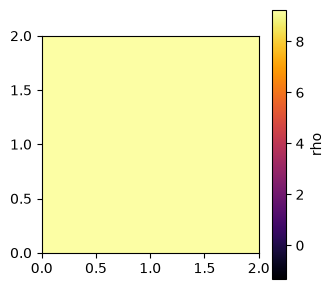

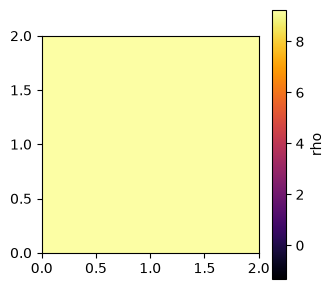

In [4]:
velocity = make_velocity(field="rotation_expansion", alpha_mode="const", alpha=10.0, beta_mode="const", beta=0.0)
source = make_source(mode="temporary", amp=0, sigma=1, center=(0, 0), period=1)
def implicit_source(x, y, t, u):
    return 0.0
implicit_source = make_source(mode="logistic", A=1, B=10)
rectangle = {
    "x_range": (-1, 1),
    "y_range": (-1, 1),
    "dx": 0.02,
    "dy": 0.02
}
rectangle_bc = {
    "left": ("Neumann", 0.0),
    "top": ("Neumann", 0.0),
    "right":("Neumann", 0.0),
    "bottom": ("Neumann", 0.0)
}
circle = {
    "cell_size": 0.02,
    "radius": 1
}
circle_bc = {
    "mode": "Neumann",
    "value": 0.0
}
ic = {
    "gaussian": True,
    "periodic_circles": False,
    "periodic_valleys": False,
    "periodic_stripes": False,
    "periodic_grid": False,
    "uniform_noise": False,
    "u0": 0.0,
    "centers": [(0.0, 0.0), (0.5, 0.5)], "amps": [6, 5], "sigmas": [0.2, 0.5],
    "A": 0, "Ax": 0, "Ay": 0,
    "B": 0, "Bx": 0, "By": 0,
    "Cx": 0, "Cy": 0,
    "D": 0,
    "min_noise": 0, "max_noise": 0
}
dataset = generate_AdvectionReactionDiffusion(
    velocity=velocity, 
    source=source, 
    implicit_source=implicit_source, 
    shape="rectangle", 
    spatial_region=rectangle, 
    bc=rectangle_bc, 
    ic=ic, 
    t0=0, tN=2.0, dt=0.2, 
    n_snapshots=10, snapshot_start=0.0, 
    diffusion_coeff=0.1, 
    include_bc=True, 
    include_diffusion_coeff=True, 
    include_source_values=True, 
    include_velocity_values=True, 
    include_implicit_source_A=True, 
    include_implicit_source_B=True, 
    A=1, 
    B=10
)

#dataset = generate_AdvectionReactionDiffusion_unlabeled(X=get_grid([-1.0, -1.0], [1.0,1.0], [0.01, 0.01]), velocity=velocity, source=source, shape="rectangle", bc=rectangle_bc, snapshots=[0,0.1,0.2,0.3], diffusion_coeff=0.1, include_bc=True, include_diffusion_coeff=True, include_source_values=True, include_velocity_values=True)

In [5]:
dataset.datasets[0].cols["bc"]

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        ...,
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

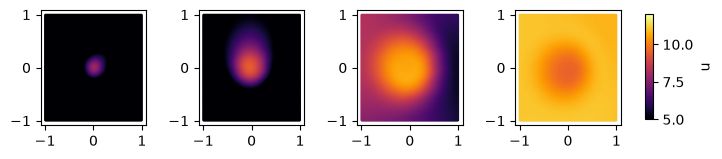

In [6]:
plot_points(datasets=dataset.datasets[:4], key_inputs="spacetime", key_labels="u", nrows=1, ncols=4, figsize=(8, 1.5), vmins=5, vmaxs=12)

In [7]:
dataset.datasets[0].cols.items()

dict_items([('spacetime', tensor([[-0.9900, -0.9900,  0.0000],
        [-0.9700, -0.9900,  0.0000],
        [-0.9500, -0.9900,  0.0000],
        ...,
        [ 0.9500,  0.9900,  0.0000],
        [ 0.9700,  0.9900,  0.0000],
        [ 0.9900,  0.9900,  0.0000]], dtype=torch.float64)), ('u', tensor([6.9544e-04, 7.8286e-04, 8.7985e-04,  ..., 2.0632e+00, 1.9886e+00,
        1.9137e+00], dtype=torch.float64)), ('du', tensor([[ 2.1853e-03,  2.1853e-03,  0.0000e+00],
        [ 4.6101e-03,  2.4600e-03,  0.0000e+00],
        [ 5.1105e-03,  2.7648e-03,  0.0000e+00],
        ...,
        [-3.7115e+00, -2.0192e+00,  0.0000e+00],
        [-3.7365e+00, -1.9462e+00,  0.0000e+00],
        [-1.8729e+00, -1.8729e+00,  0.0000e+00]], dtype=torch.float64)), ('d2u', tensor([[[ 6.7487e+00,  6.8671e-03,  0.0000e+00],
         [ 6.8671e-03,  6.7487e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00]],

        [[-3.3624e+00,  1.4487e-02,  0.0000e+00],
         [ 1.4487e-02,  6.8992e+00,  0.0000

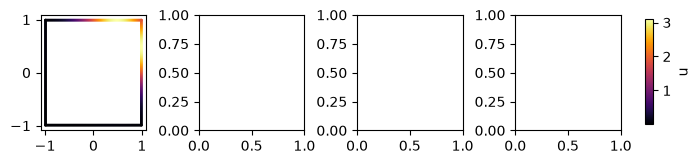

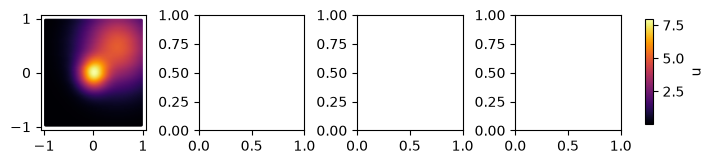

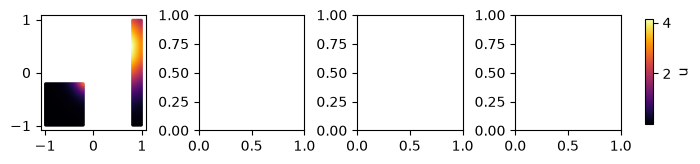

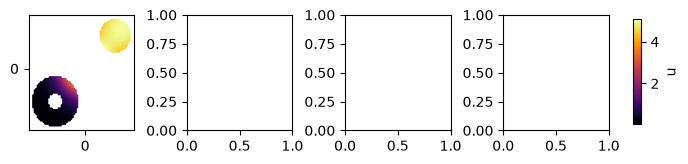

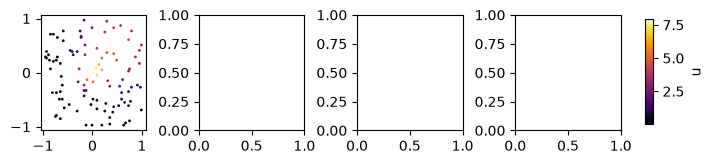

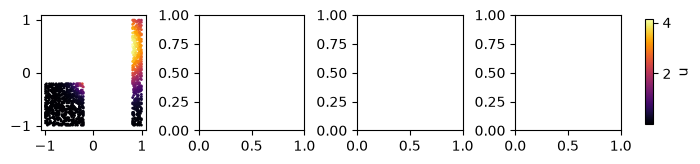

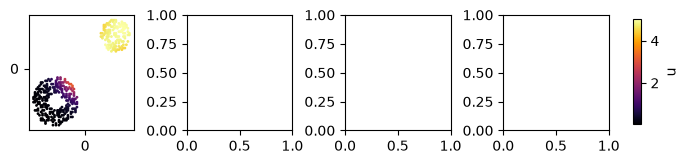

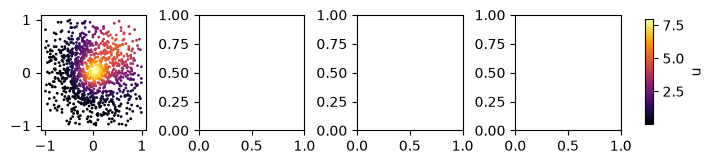

In [8]:
ds = dataset.datasets[0]

#bd = extract_boundary(dataset=ds, shape="circle", cell_size=0.02, center=[0, 0], radius=1.0)
bd = extract_boundary(dataset=ds, shape="rectangle")
plot_points(datasets=bd, key_inputs="spacetime", key_labels="u", nrows=1, ncols=4, figsize=(8, 1.5))
#interior = extract_interior(dataset=ds, shape="circle", cell_size=0.02, center=[0, 0], radius=1.0)
interior = extract_interior(dataset=ds, shape="rectangle")
plot_points(datasets=interior, key_inputs="spacetime", key_labels="u", nrows=1, ncols=4, figsize=(8, 1.5))

rectangle = [{"x": (-1, -0.2), "y": (-1, -0.2)}, {"x": (0.8, 1.0), "y": (-1, 1)}]
circle = [{"x": -0.4, "y": -0.4, "r": [0.1, 0.3]}, {"x": 0.4, "y": 0.4, "r": [0.0, 0.2]}]

sc = extract_Dataset(dataset=ds, shape="circle", time_indexes=[0], spatial_ranges=circle)
sr = extract_Dataset(dataset=ds, shape="rectangle", time_indexes=[0], spatial_ranges=rectangle)
plot_points(datasets=sr, key_inputs="spacetime", key_labels="u", nrows=1, ncols=4, figsize=(8, 1.5))
plot_points(datasets=sc, key_inputs="spacetime", key_labels="u", nrows=1, ncols=4, figsize=(8, 1.5))

subset = subsample(dataset=ds, n_samples=100)
plot_points(datasets=subset, key_inputs="spacetime", key_labels="u", nrows=1, ncols=4, figsize=(8, 1.5))

subset = subsample(dataset=sr, n_samples=1000)
plot_points(datasets=subset, key_inputs="spacetime", key_labels="u", nrows=1, ncols=4, figsize=(8, 1.5))

subset = subsample(dataset=sc, n_samples=400)
plot_points(datasets=subset, key_inputs="spacetime", key_labels="u", nrows=1, ncols=4, figsize=(8, 1.5))

subset = subsample_normal(dataset=ds, mean=torch.tensor([0.0, 0.0]), stddev=0.5, n_samples=1000)
plot_points(datasets=subset, key_inputs="spacetime", key_labels="u", nrows=1, ncols=4, figsize=(8, 1.5))

In [9]:
X = get_grid(xmin_list=[-1, -1], xmax_list=[1, 1], dx_list=[0.01, 0.01])
#X = get_circle(radius=1, dx_list=[0.01, 0.01])

/Users/cla/tesi/PinnsStudy/myenv/lib/python3.11/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4384.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [10]:
X

tensor([[-1.0000, -1.0000],
        [-1.0000, -0.9900],
        [-1.0000, -0.9800],
        ...,
        [ 1.0000,  0.9800],
        [ 1.0000,  0.9900],
        [ 1.0000,  1.0000]])

In [17]:
dataset = generate_AllenCahn(lam=0.1, xi=[0.1, 0.2, 3, -2, 10], X=X, include_lam=True, include_xi=True)

In [18]:
dataset.cols

{'spacetime': tensor([[-1.0000, -1.0000],
         [-1.0000, -0.9900],
         [-1.0000, -0.9800],
         ...,
         [ 1.0000,  0.9800],
         [ 1.0000,  0.9900],
         [ 1.0000,  1.0000]]),
 'u': tensor([3.6284e-15, 4.2622e-09, 8.4233e-09,  ..., 8.4233e-09, 4.2623e-09,
         3.6284e-15]),
 'du': tensor([[ 4.2792e-07,  4.2792e-07],
         [ 2.2226e-01,  4.2284e-07],
         [ 4.3975e-01,  4.0772e-07],
         ...,
         [-4.3975e-01, -4.0772e-07],
         [-2.2226e-01, -4.2284e-07],
         [-4.2792e-07, -4.2792e-07]]),
 'd2u': tensor([[[-1.0613e-12,  2.2305e+01],
          [ 2.2305e+01, -1.0613e-12]],
 
         [[-1.0137e-06,  2.2066e+01],
          [ 2.2066e+01, -1.0137e-06]],
 
         [[-2.0037e-06,  2.1355e+01],
          [ 2.1355e+01, -2.0037e-06]],
 
         ...,
 
         [[-2.0037e-06,  2.1355e+01],
          [ 2.1355e+01, -2.0037e-06]],
 
         [[-1.0137e-06,  2.2066e+01],
          [ 2.2066e+01, -1.0137e-06]],
 
         [[-1.0613e-12,  2.2305e

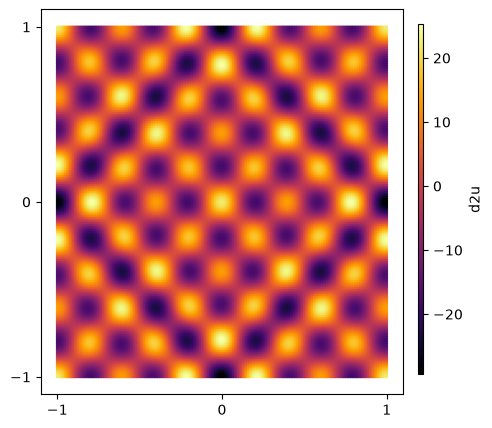

In [32]:
plot_points(datasets=dataset, show=True, key_inputs="spacetime", key_labels="d2u", label_idxs=[(1,0)])